In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch9.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch8.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch6.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch4.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch7.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch2.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch3.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch10.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch5.dat
/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch1.dat


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
import joblib 
sns.set(style="whitegrid")


# DATA LOADING


In [3]:
# List to hold data from all batches
all_batches = []

for i in range(1, 8):
    path = f'/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch{i}.dat'
    print(f"Loading Batch {i}...")
    
    # Load the file
    temp_df = pd.read_csv(path, sep='\s+', header=None)
    all_batches.append(temp_df)

# Concatenate (merge) all batches into one DataFrame
df = pd.concat(all_batches, ignore_index=True)

print(f"Merged Data Shape: {df.shape}")

# --- Cleaning Steps (Same as before) ---
# Separate Label and Features
train_data = df.iloc[:, 1:]

# Fix the "Key:Value" format
def clean_value(x):
    # Convert to string, split by ':', take the last part, convert to float
    return float(str(x).split(':')[-1])

print("Cleaning data format (this may take a minute)...")
train_data = train_data.applymap(clean_value)

print("Data Cleaned Successfully.")
print(f"Final Training Shape: {train_data.shape}") 
print(train_data.head())

Loading Batch 1...
Loading Batch 2...
Loading Batch 3...
Loading Batch 4...
Loading Batch 5...
Loading Batch 6...
Loading Batch 7...
Merged Data Shape: (9546, 129)
Cleaning data format (this may take a minute)...
Data Cleaned Successfully.
Final Training Shape: (9546, 128)
          1         2          3          4          5          6    \
0  15596.1621  1.868245   2.371604   2.803678   7.512213  -2.739388   
1  26402.0704  2.532401   5.411209   6.509906   7.658469  -4.722217   
2  42103.5820  3.454189   8.198175  10.508439  11.611003  -7.668313   
3  42825.9883  3.451192  12.113940  16.266853  39.910056  -7.849409   
4  58151.1757  4.194839  11.455096  15.715298  17.654915 -11.083364   

         7          8           9         10   ...       119       120  \
0  -3.344671  -4.847512  15326.6914  1.768526  ... -1.071137 -3.037772   
1  -5.817651  -7.518333  23855.7812  2.164706  ... -1.530519 -1.994993   
2  -9.478675 -12.230939  37562.3008  2.840403  ... -2.384784 -2.867291   
3  

/tmp/ipykernel_48/1597208690.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_data = train_data.applymap(clean_value)


# DATA PREPROCESSING

In [4]:

# 1. Load and Combine Raw Data
all_batches = []
print("Loading Batches 1 through 10...")

for i in range(1, 8):
    path = f'/kaggle/input/gas-sensor-array-drift-dataset/Dataset/batch{i}.dat'
    # Load raw batch
    temp_df = pd.read_csv(path, sep='\s+', header=None)
    all_batches.append(temp_df)
    print(f"Batch {i} loaded.")

# Merge into one big DataFrame
df_combined = pd.concat(all_batches, ignore_index=True)

# 2. Separate Label and Features
# Column 0 is the label (we drop it), Columns 1+ are sensors
train_data = df_combined.iloc[:, 1:]

# 3. Clean the Data (Apply to the WHOLE combined dataset)
def clean_value(x):
    # Splits "1:12.34" -> takes "12.34" -> converts to float
    return float(str(x).split(':')[-1])

print("Cleaning combined data (stripping prefixes)... This might take 1-2 minutes.")
train_data = train_data.applymap(clean_value)

print("Data Cleaned Successfully.")
print(f"Total Combined Shape: {train_data.shape}") 
print(train_data.head())

Loading Batches 1 through 10...
Batch 1 loaded.
Batch 2 loaded.
Batch 3 loaded.
Batch 4 loaded.
Batch 5 loaded.
Batch 6 loaded.
Batch 7 loaded.
Cleaning combined data (stripping prefixes)... This might take 1-2 minutes.
Data Cleaned Successfully.
Total Combined Shape: (9546, 128)
          1         2          3          4          5          6    \
0  15596.1621  1.868245   2.371604   2.803678   7.512213  -2.739388   
1  26402.0704  2.532401   5.411209   6.509906   7.658469  -4.722217   
2  42103.5820  3.454189   8.198175  10.508439  11.611003  -7.668313   
3  42825.9883  3.451192  12.113940  16.266853  39.910056  -7.849409   
4  58151.1757  4.194839  11.455096  15.715298  17.654915 -11.083364   

         7          8           9         10   ...       119       120  \
0  -3.344671  -4.847512  15326.6914  1.768526  ... -1.071137 -3.037772   
1  -5.817651  -7.518333  23855.7812  2.164706  ... -1.530519 -1.994993   
2  -9.478675 -12.230939  37562.3008  2.840403  ... -2.384784 -2.867291

/tmp/ipykernel_48/1501204485.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_data = train_data.applymap(clean_value)


# Scale the Data

In [5]:
# Scale the Combined Data
scaler = StandardScaler()

# We fit the scaler on ALL 5 batches so it knows the global min/max
X_scaled = scaler.fit_transform(train_data)

print(f"Data Scaled. Final matrix shape: {X_scaled.shape}")

Data Scaled. Final matrix shape: (9546, 128)


# Initialize OCSVM

In [6]:

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

model.fit(X_scaled)
print("Training Complete.")

Training Complete.


# Outliers Detected in OCSVM

In [7]:
# Predict on the full 10-batch dataset
# -1 = Outlier, 1 = Normal
predictions = model.predict(X_scaled)

# Get the anomaly scores (useful for setting thresholds later)
scores = model.decision_function(X_scaled)

# Calculate stats
total = len(predictions)
n_outliers = list(predictions).count(-1)
percent = (n_outliers / total) * 100

print(f"Total Samples: {total}")
print(f"Outliers Detected: {n_outliers} ({percent:.2f}%)")

Total Samples: 9546
Outliers Detected: 477 (5.00%)


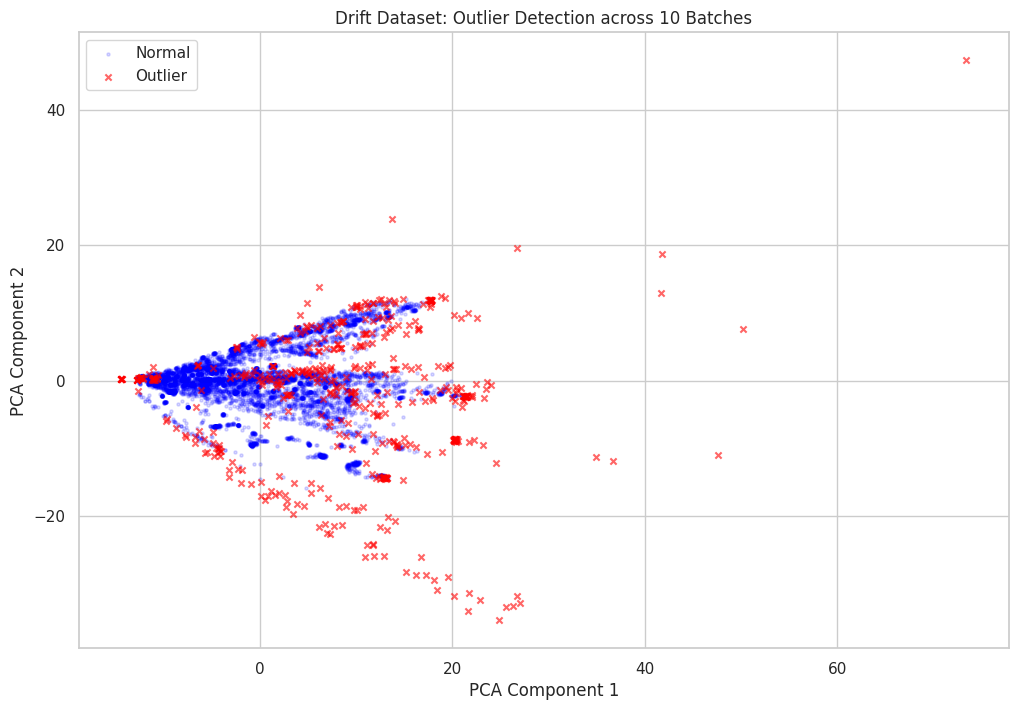

In [8]:
from sklearn.decomposition import PCA

# Compress 128 dimensions -> 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

# Plot Normal (Blue) - using low alpha (transparency) because data is dense
plt.scatter(X_pca[predictions == 1, 0], X_pca[predictions == 1, 1], 
            c='blue', label='Normal', alpha=0.15, s=5)

# Plot Outliers (Red)
plt.scatter(X_pca[predictions == -1, 0], X_pca[predictions == -1, 1], 
            c='red', label='Outlier', alpha=0.6, s=20, marker='x')

plt.title('Drift Dataset: Outlier Detection across 10 Batches')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

In [9]:
import joblib

# Save the trained model and the scaler
joblib.dump(model, 'ocsvm_model_10batch.pkl')
joblib.dump(scaler, 'scaler_10batch.pkl')

print("SUCCESS: Model and Scaler saved.")
print("Please download 'ocsvm_model_10batch.pkl' and 'scaler_10batch.pkl' from the Output section.")

SUCCESS: Model and Scaler saved.
Please download 'ocsvm_model_10batch.pkl' and 'scaler_10batch.pkl' from the Output section.


# Initialize Isolation Forest

In [10]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest
# contamination=0.05: Same assumption as 'nu' (5% outliers)
# random_state=42: Ensures reproducible results
iso_model = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)

print("Training Isolation Forest on Batches 1-7...")
iso_model.fit(X_scaled)
print("Training Complete.")

Training Isolation Forest on Batches 1-7...
Training Complete.


# Outliers Detected in Isolation Forest

In [11]:
# 1. Get Predictions from Isolation Forest
# -1 = Outlier, 1 = Normal
iso_predictions = iso_model.predict(X_scaled)

# 2. Get Predictions from OCSVM (re-running predict just to be sure)
ocsvm_predictions = model.predict(X_scaled)

# 3. Create a Comparison DataFrame
comparison = pd.DataFrame({
    'OCSVM': ocsvm_predictions,
    'IsoForest': iso_predictions
})

# 4. Calculate Stats
ocsvm_outliers = (comparison['OCSVM'] == -1).sum()
iso_outliers = (comparison['IsoForest'] == -1).sum()

# How many times did BOTH say "This is an outlier"?
agreement = ((comparison['OCSVM'] == -1) & (comparison['IsoForest'] == -1)).sum()

print(f"--- Comparison Results ---")
print(f"OCSVM detected outliers:       {ocsvm_outliers}")
print(f"IsoForest detected outliers:   {iso_outliers}")
print(f"Both agreed on:                {agreement} data points")

# Calculate Jaccard Similarity (Overlap percentage)
# Intersection / Union
union = len(comparison[(comparison['OCSVM'] == -1) | (comparison['IsoForest'] == -1)])
similarity = (agreement / union) * 100 if union > 0 else 0
print(f"Overlap Similarity:            {similarity:.2f}%")

--- Comparison Results ---
OCSVM detected outliers:       477
IsoForest detected outliers:   478
Both agreed on:                270 data points
Overlap Similarity:            39.42%


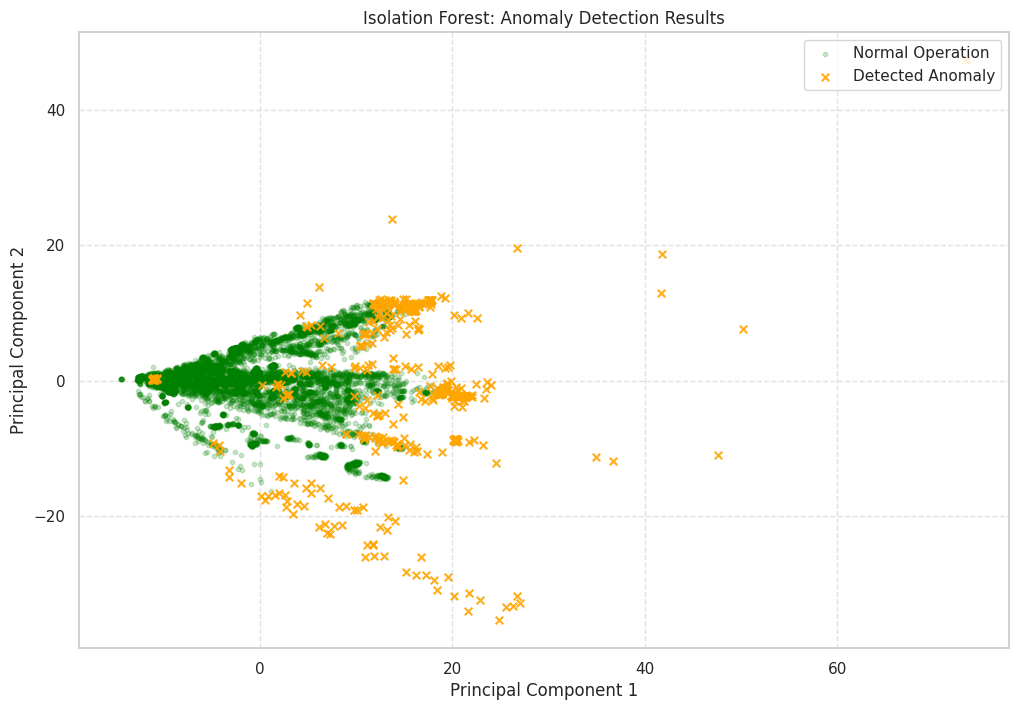

In [12]:
# Ensure predictions are ready
iso_predictions = iso_model.predict(X_scaled)

plt.figure(figsize=(12, 8))

# 1. Plot Normal Data (Green)
# We use alpha=0.2 (transparency) so we can see density
plt.scatter(X_pca[iso_predictions == 1, 0], X_pca[iso_predictions == 1, 1], 
            c='green', label='Normal Operation', alpha=0.2, s=10)

# 2. Plot Outliers (Red)
# We make these larger (s=30) and opaque so they stand out
plt.scatter(X_pca[iso_predictions == -1, 0], X_pca[iso_predictions == -1, 1], 
            c='orange', label='Detected Anomaly', alpha=0.9, s=30, marker='x')

plt.title('Isolation Forest: Anomaly Detection Results')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [13]:
joblib.dump(iso_model, 'iso_forest_10batch.pkl')
print("Isolation Forest model saved as 'iso_forest_10batch.pkl'")

Isolation Forest model saved as 'iso_forest_10batch.pkl'


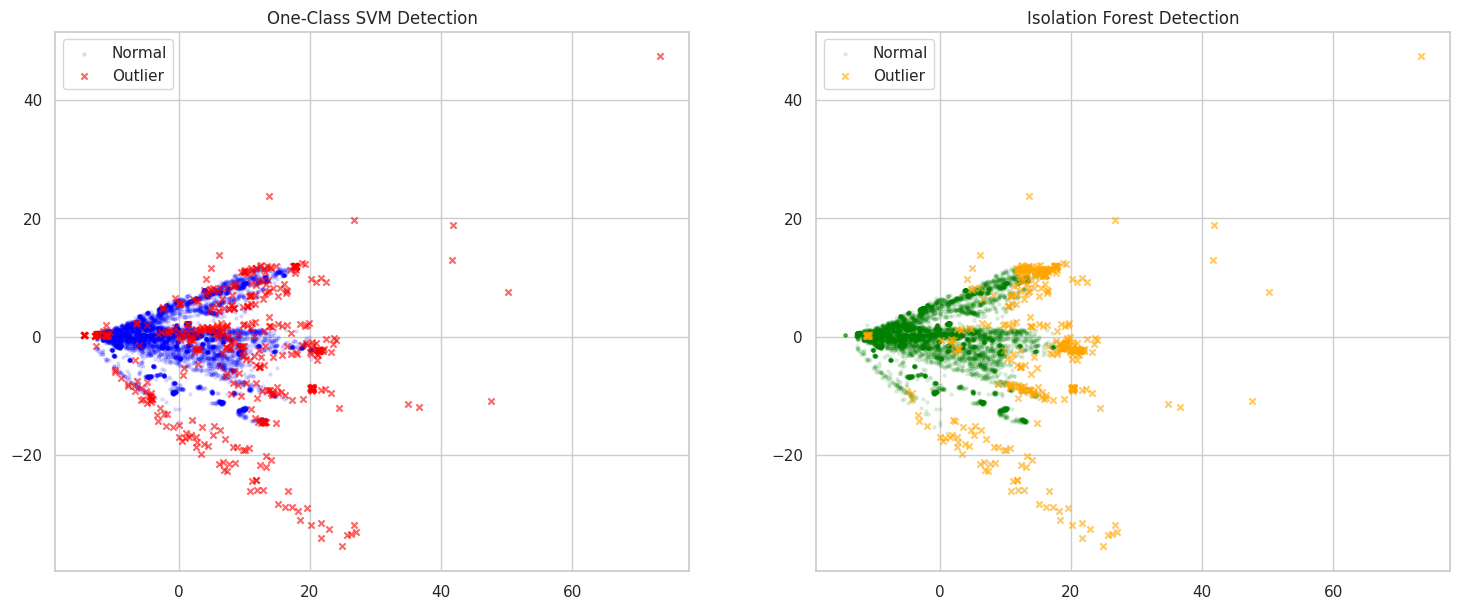

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Use the same PCA coordinates calculated earlier (X_pca)
# -----------------------------
# Plot 1: OCSVM
# -----------------------------
axes[0].scatter(X_pca[ocsvm_predictions == 1, 0], X_pca[ocsvm_predictions == 1, 1], 
                c='blue', alpha=0.1, s=5, label='Normal')
axes[0].scatter(X_pca[ocsvm_predictions == -1, 0], X_pca[ocsvm_predictions == -1, 1], 
                c='red', alpha=0.6, s=20, marker='x', label='Outlier')
axes[0].set_title('One-Class SVM Detection')
axes[0].legend()

# -----------------------------
# Plot 2: Isolation Forest
# -----------------------------
axes[1].scatter(X_pca[iso_predictions == 1, 0], X_pca[iso_predictions == 1, 1], 
                c='green', alpha=0.1, s=5, label='Normal')
axes[1].scatter(X_pca[iso_predictions == -1, 0], X_pca[iso_predictions == -1, 1], 
                c='orange', alpha=0.6, s=20, marker='x', label='Outlier')
axes[1].set_title('Isolation Forest Detection')
axes[1].legend()

plt.show()

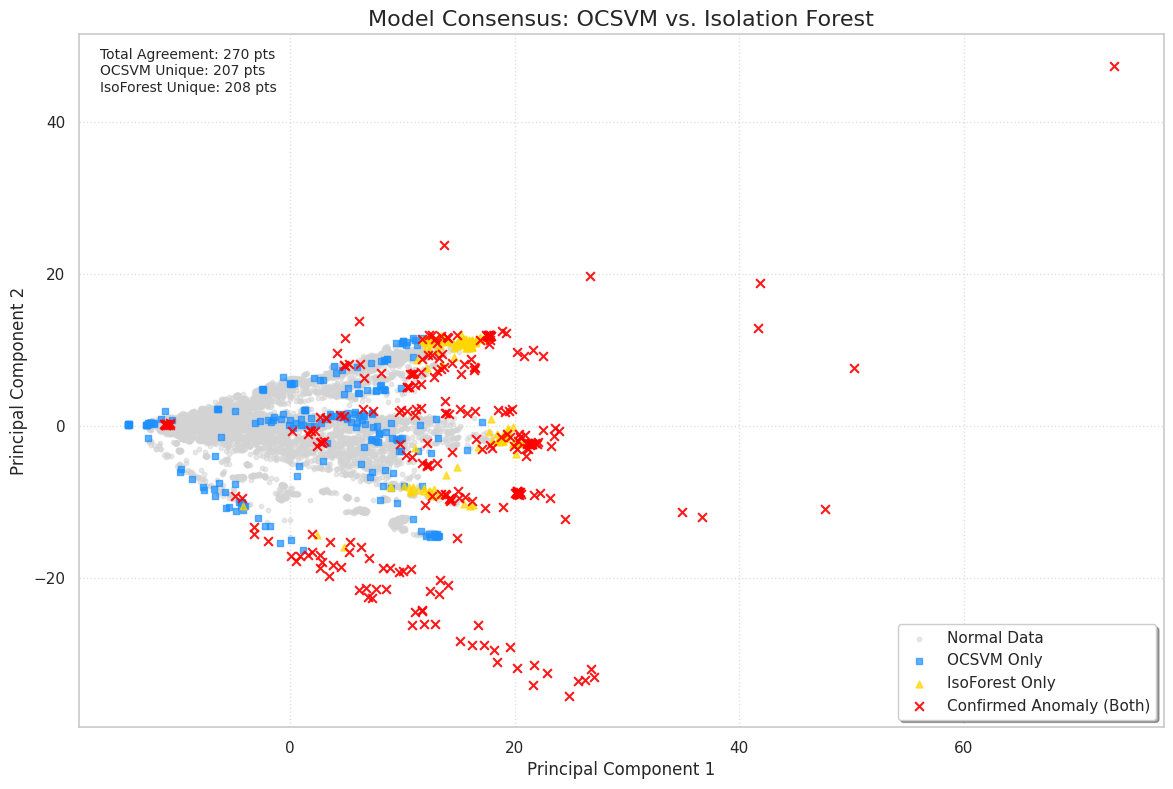

In [15]:
import matplotlib.patches as mpatches

plt.figure(figsize=(14, 9))

# 1. Create boolean masks for the 4 categories
# (Remember: 1 is Normal, -1 is Outlier)
mask_normal = (ocsvm_predictions == 1) & (iso_predictions == 1)
mask_ocsvm_only = (ocsvm_predictions == -1) & (iso_predictions == 1)
mask_iso_only = (ocsvm_predictions == 1) & (iso_predictions == -1)
mask_both = (ocsvm_predictions == -1) & (iso_predictions == -1)

# 2. Plot Normal Data (Grey background)
plt.scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1], 
            c='lightgrey', alpha=0.5, s=10, label='Normal Data')

# 3. Plot Disagreements (Yellow and Blue)
plt.scatter(X_pca[mask_ocsvm_only, 0], X_pca[mask_ocsvm_only, 1], 
            c='dodgerblue', alpha=0.7, s=25, marker='s', label='OCSVM Only')

plt.scatter(X_pca[mask_iso_only, 0], X_pca[mask_iso_only, 1], 
            c='gold', alpha=0.7, s=25, marker='^', label='IsoForest Only')

# 4. Plot Agreement (Red - The "True" Anomalies)
plt.scatter(X_pca[mask_both, 0], X_pca[mask_both, 1], 
            c='red', alpha=0.9, s=40, marker='x', label='Confirmed Anomaly (Both)')

# Styling
plt.title('Model Consensus: OCSVM vs. Isolation Forest', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Add stats to the plot title or text
text_str = (f"Total Agreement: {mask_both.sum()} pts\n"
            f"OCSVM Unique: {mask_ocsvm_only.sum()} pts\n"
            f"IsoForest Unique: {mask_iso_only.sum()} pts")
plt.text(0.02, 0.98, text_str, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()